# Establishing AED Deployment Optimization Baseline
This notebook analyzes the Out-of-Hospital Cardiac Arrest (OHCA) clinical dataset to build a probability baseline that will inform the objective function for future stochastic AED deployment models.

This analysis strictly isolates **Bystander AED interventions** and visualizes how application delays impact a patient's long-term neurological recovery.

**Key Metrics:**
* **Duration (X-Axis):** Time from the initial dispatch call to the first bystander AED shock (in minutes).
* **Objective Outcome (Y-Axis):** Patient Neurological Status at discharge/30-days, comparing Good Outcomes (CPC 1 & 2) against Poor Outcomes / Mortality (CPC 3, 4, 5).
* **Eligible Cohort:** Strictly limited to recorded cases where a bystander actively applied the AED (excluding AEDs applied by SCDF/EMS personnel).

# Need to install decryption Libraries

In [17]:
%pip install msoffcrypto-tool openpyxl

Note: you may need to restart the kernel to use updated packages.


# Install libraries

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import msoffcrypto
import io
import openpyxl

from pathlib import Path
from lifelines import KaplanMeierFitter

# Get the password from env

In [19]:
password = os.getenv("PAROS_PASSWORD")

if not password:
    print("ERROR: Password not found in the env")
else:
    print("SUCCESS: Password found in the env")

SUCCESS: Password found in the env


# Setting up file paths

In [20]:
CURRENT_DIRECTORY = Path(os.getcwd())
BASE_DATASET_PATH = CURRENT_DIRECTORY.parents[0] / "datasets"
ENCRYPTED_FILE_PATH = BASE_DATASET_PATH / "DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx"

display(ENCRYPTED_FILE_PATH)


PosixPath('/Users/axlee/Desktop/Singhealth/AED-OHCA/datasets/DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx')

# Decrypting the file

In [21]:
decrypted_workbook = io.BytesIO()
print(f"Attempting to decrypt: {ENCRYPTED_FILE_PATH.name}...")

try:
    with open(ENCRYPTED_FILE_PATH, 'rb') as file:
        office_file = msoffcrypto.OfficeFile(file)
        office_file.load_key(password=password)
        office_file.decrypt(decrypted_workbook)

    # Load the decrypted memory object directly into a Pandas DataFrame
    df = pd.read_excel(decrypted_workbook)
    print("✅ RAW PAROS dataset successfully decrypted and loaded!")
    
    # Show the first 3 rows to confirm
    display(df.head(3))

except FileNotFoundError:
    print(f"❌ Error: Could not find the file at {ENCRYPTED_FILE_PATH}. Please check the path and filename.")
except openpyxl.utils.exceptions.InvalidFileException:
    print("❌ Error: Invalid password or unsupported Excel format.")
except Exception as e:
    print(f"❌ An error occurred: {e}")

Attempting to decrypt: DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx...


/opt/miniconda3/envs/geospatial_env/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


✅ RAW PAROS dataset successfully decrypted and loaded!


,Case #,Country,City,Site #,Patient brought in by,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,...,EQ-5D Unknown,EQ-5D Mobility,EQ-5D Self-care,EQ-5D Usual activities,EQ-5D Pain/Discomfort,EQ-5D Anxiety/Depression,EQ-5D VAS,General Comments,Date Created,Date Last Saved
0,SGSIN0213,SG,SIN,2,EMS,2010-04-01,470146.0,NaN,Home Residence,HDB Level 7,...,NaN,,,,,,NaN,,,2011-02-22
1,SGSIN0218,SG,SIN,2,EMS,2010-04-01,520926.0,NaN,Home Residence,HDB Level 2,...,NaN,,,,,,NaN,,,2011-02-22
2,SGSIN6480,SG,SIN,6,EMS,2010-04-01,560565.0,NaN,Healthcare Facility,NKF Dialysis Centre,...,NaN,,,,,,NaN,,,2012-04-18


# Creating the Eras

In [22]:
df['Date of Incident'] = pd.to_datetime(df['Date of Incident'],
                                        format='mixed',
                                        errors='coerce')
df['Year'] = df['Date of Incident'].dt.year

era1 = df[(df['Year'] >= 2010) & (df['Year'] <= 2017)].copy()
era2 = df[(df['Year'] >= 2018) & (df['Year'] <= 2021)].copy()

print(f"Era 1 (2010-2017) patient count: {len(era1)}")
print(f"Era 2 (2018-2021) patient count: {len(era2)}")

Era 1 (2010-2017) patient count: 15390
Era 2 (2018-2021) patient count: 13275


# Creating the columns needed for this dataframe

In [23]:
bystander_aed_col = 'Bystander AED applied'
call_time_col = 'Time call received at dispatch center'
shock_time_col = 'Time of first shock given'
cpc_col = 'Patient neurological status - Cerebral'

# Define Eligible Cohort

Has to be a bystander AED (Excluding SCDF/EMS-only AED applications)

In [24]:
cohort = df[df[bystander_aed_col].astype(str).str.contains('Yes',
                                                           case=False,
                                                           na=False)].copy()

# To drop rows with missing the exact timestamps or CPC scores needed
cohort = cohort.dropna(subset=[call_time_col,
                               shock_time_col,
                               cpc_col]).copy()

display(cohort.head())

,Case #,Country,City,Site #,Patient brought in by,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,...,EQ-5D Mobility,EQ-5D Self-care,EQ-5D Usual activities,EQ-5D Pain/Discomfort,EQ-5D Anxiety/Depression,EQ-5D VAS,General Comments,Date Created,Date Last Saved,Year
1620,SGSIN022392,SG,SIN,2,EMS,2011-05-09,506981.0,NaN,Other,Prison,...,,,,,,,,,2012-06-21,2011
1889,SGSIN013907,SG,SIN,1,EMS,2011-07-11,148958.0,NaN,Healthcare Facility,Level 03,...,,,,,,,,,2016-05-11,2011
3135,SGSIN0072961,SG,SIN,7,EMS,2012-06-29,99981.0,NaN,Place of Recreation,,...,No problem,No problem,No problem,NaN,NaN,80,,,2017-11-09,2012
3500,SGSIN026477,SG,SIN,2,EMS,2012-09-23,499803.0,NaN,Place of Recreation,level 1,...,,,,,,,,,2016-04-25,2012
5451,SGSIN0610183,SG,SIN,6,EMS,2013-11-20,380102.0,NaN,Healthcare Facility,102 Aljunied Crescent NKF Dialysis Center,...,,,,,,,,,2016-03-30,2013


# Engineer Time to Bystander AED application (in minutes)

In [25]:
cohort['Call_Time'] = pd.to_datetime(cohort[call_time_col].astype(str),
                                     format='mixed',
                                     errors='coerce')
cohort['Shock_Time'] = pd.to_datetime(cohort[shock_time_col].astype(str),
                                      format='mixed',
                                      errors='coerce')

# Drop missing timestamps after conversion
cohort = cohort.dropna(subset=['Call_Time', 'Shock_Time']).copy()

display(cohort[['Call_Time', 'Shock_Time']].head())

,Call_Time,Shock_Time
1620,2026-03-19 11:14:11,2026-03-19 11:54:45
1889,2026-03-19 10:19:35,2026-03-19 10:17:00
3135,2026-03-19 14:36:00,2026-03-19 14:36:00
3500,2026-03-19 12:07:14,2026-03-19 12:19:55
5451,2026-03-19 15:37:00,2026-03-19 15:45:19


# Calculate differences (in minutes)

In [26]:
cohort['Time_to_AED_mins'] = (cohort['Shock_Time'] - cohort['Call_Time']).dt.total_seconds() / 60.0

# Fix midnight crossover overlap issues
cohort.loc[cohort['Time_to_AED_mins'] < 0, 'Time_to_AED_mins'] += 1440

# Clean outliers
cohort = cohort[(cohort['Time_to_AED_mins'] >= 0) & (cohort['Time_to_AED_mins'] <= 60)].copy()

display(cohort["Time_to_AED_mins"].head())

1620    40.566667
3135     0.000000
3500    12.683333
5451     8.316667
6469     2.133333
Name: Time_to_AED_mins, dtype: float64

# Define Outcome: Good CPC (1 or 2) = 1, Poor or Death (3, 4, 5, etc.) = 0

In [27]:
cohort['Good_CPC'] = cohort[cpc_col].astype(str).str.contains('1|2', regex=True).astype(int)
cohort['Bad_CPC'] = cohort[cpc_col].astype(str).str.contains('3|4|5', regex=True).astype(int)


print(f"Eligible Bystander-AED Cohort Size: {len(cohort)}")

Eligible Bystander-AED Cohort Size: 42


# Transform the data into 5-minute interval blocks to find the probability at each stage

In [28]:
cohort['Time_Bin_5Min'] = (cohort['Time_to_AED_mins'] // 5) * 5
binned_prob = cohort.groupby('Time_Bin_5Min')[['Good_CPC', 'Bad_CPC']].mean().reset_index()
display(binned_prob)

,Time_Bin_5Min,Good_CPC,Bad_CPC
0,0.0,0.750000,0.000000
1,5.0,0.888889,0.000000
2,10.0,0.733333,0.133333
3,15.0,0.875000,0.125000
4,20.0,1.000000,0.000000
5,35.0,0.000000,0.500000
6,40.0,0.000000,0.000000


# Plotting the graph

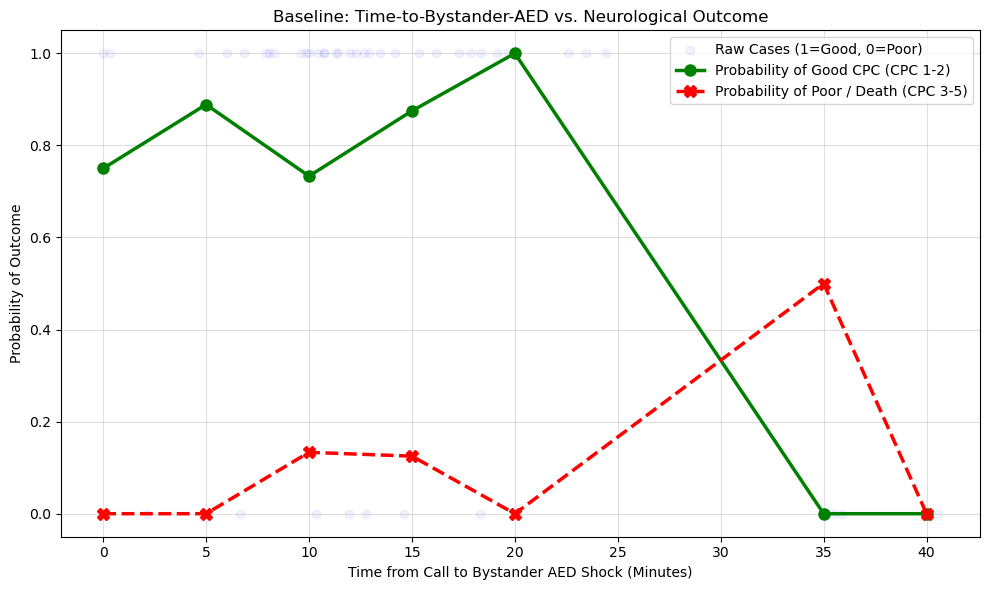

In [29]:
plt.figure(figsize=(10, 6))

# Plot the raw individual outcomes as faint dots (1 = Good CPC, 0 = Poor/Death)
plt.scatter(cohort['Time_to_AED_mins'],
            cohort['Good_CPC'], 
            alpha=0.05,
            color='blue',
            label='Raw Cases (1=Good, 0=Poor)')

# Plot Good CPC line
plt.plot(binned_prob['Time_Bin_5Min'],
         binned_prob['Good_CPC'], 
         marker='o',
         color='green',
         linewidth=2.5,
         markersize=8, 
         label='Probability of Good CPC (CPC 1-2)')

# Plot Bad CPC line
plt.plot(binned_prob['Time_Bin_5Min'],
         binned_prob['Bad_CPC'], 
         marker='X',
         color='red',
         linewidth=2.5,
         markersize=8,
         linestyle='--',
         label='Probability of Poor / Death (CPC 3-5)')

plt.title('Baseline: Time-to-Bystander-AED vs. Neurological Outcome')
plt.xlabel('Time from Call to Bystander AED Shock (Minutes)')
plt.ylabel('Probability of Outcome')
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()